<h1>Scenario Forecasting and Risk Mitigation</h1>

<h3>Ivan Komin</h3>

<h3>Group: IP-44</h3>

<h3>Introduction</h3>

Modern environmental monitoring generates vast volumes of time-structured data. By aggregating this data annually, we can treat individual years as "snapshots" of environmental conditions. We will use the K-means clustering algorithm to group these years by their overall climate profiles, allowing us to identify stable versus unfavorable scenarios.

<h3>1. Load and Clean Raw Data</h3>

We start by loading the daily weather data from our Excel file. We must clean the column headers to ensure the SQL engine can parse them without errors.

In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set plot style for better readability
plt.style.use('seaborn-v0_8-muted')

# Load the dataset
df_daily = pd.read_excel("Kyiv.xlsx")

# Clean column names: remove units in parentheses and standardize moisture labels
df_daily.columns = [col.split(' (')[0].strip().replace(' ', '_').lower() for col in df_daily.columns]
df_daily.columns = df_daily.columns.str.replace('0-100cm', '0_to_100cm')

print(f"Loaded {len(df_daily)} days of data.")
df_daily.head()

Loaded 31392 days of data.


,time,temperature_2m_mean,temperature_2m_max,apparent_temperature_mean,precipitation_sum,et0_fao_evapotranspiration,soil_moisture_0_to_100cm_mean,wind_speed_10m_max,relative_humidity_2m_mean,pressure_msl_mean
0,1940-01-02,-14.7,-13.0,-19.1,0.3,0.13,0.284,7.1,84,1020.3
1,1940-01-03,-15.4,-11.7,-21.6,0.5,0.22,0.284,23.2,79,1013.8
2,1940-01-04,-7.3,-5.2,-13.8,1.1,0.32,0.284,26.3,83,1008.7
3,1940-01-05,-9.1,-7.2,-15.3,0.0,0.31,0.284,24.5,81,1017.0
4,1940-01-06,-10.0,-6.9,-15.9,0.4,0.27,0.284,19.5,79,1018.9


<h3>2. Aggregate Data into Annual Indicators</h3>

Using DuckDB, we run the SQL query to condense daily data into a yearly "feature matrix". This process captures the intensity, frequency, and duration of climate risks.  

In [3]:
sql_query = """
WITH yearly_temps AS (
    SELECT
        extract(year from time) as year,
        round(avg(temperature_2m_mean), 1) as avg_year_temp,
        round(quantile_cont(temperature_2m_mean, 0.5), 1) as median_year_temp,
        min(temperature_2m_mean) as min_year_temp,
        max(temperature_2m_max) as max_year_temp
    FROM df_daily
    WHERE time BETWEEN '1950-01-01' AND '2024-12-31'
    GROUP BY 1
),
yearly_hydrology AS (
    SELECT
        extract(year from time) as year,
        count(case when precipitation_sum < 1 then 1 end) as dry_days,
        count(case when precipitation_sum >= 1 then 1 end) as rainy_days
    FROM df_daily
    WHERE time BETWEEN '1950-01-01' AND '2024-12-31'
    GROUP BY 1
)
SELECT t.*, y.dry_days, y.rainy_days
FROM yearly_temps t
JOIN yearly_hydrology y ON t.year = y.year
ORDER BY t.year
"""

df_features = duckdb.query(sql_query).to_df()
df_features.head()

,year,avg_year_temp,median_year_temp,min_year_temp,max_year_temp,dry_days,rainy_days
0,1950,7.7,9.6,-31.5,30.3,264,101
1,1951,7.9,7.9,-18.1,33.8,263,102
2,1952,6.9,7.8,-14.6,32.1,236,130
3,1953,6.9,7.3,-23.3,32.3,258,107
4,1954,6.6,7.2,-26.7,32.0,250,115


<h3>3. Establishing Climate Profiles</h3>

With the annual indicators calculated, we prepare the data for machine learning. We remove the time label and standardize the features to ensure variables with different ranges (like temperature versus day counts) are weighted equally by the algorithm.

In [4]:
# Select numerical features for the profile
X = df_features.drop(columns=['year'])

# Standardize to zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<h3>4. K-means Clustering</h3>

We apply the K-means algorithm to group the years into three distinct climate scenarios: Stable, Transitional, and Unfavorable (Extreme).

In [5]:
# Initialize and fit the model for 3 scenarios
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_features['cluster'] = kmeans.fit_predict(X_scaled)

# Display the distribution of years across scenarios
print("Years per climate scenario cluster:")
print(df_features['cluster'].value_counts())

Years per climate scenario cluster:
cluster
1    28
0    25
2    22
Name: count, dtype: int64


<h3>5. Visualization and Scenario Mapping</h3>

This visualization tracks the transition from stable historical patterns to more extreme recent conditions by plotting annual temperature against the assigned Cluster IDs.

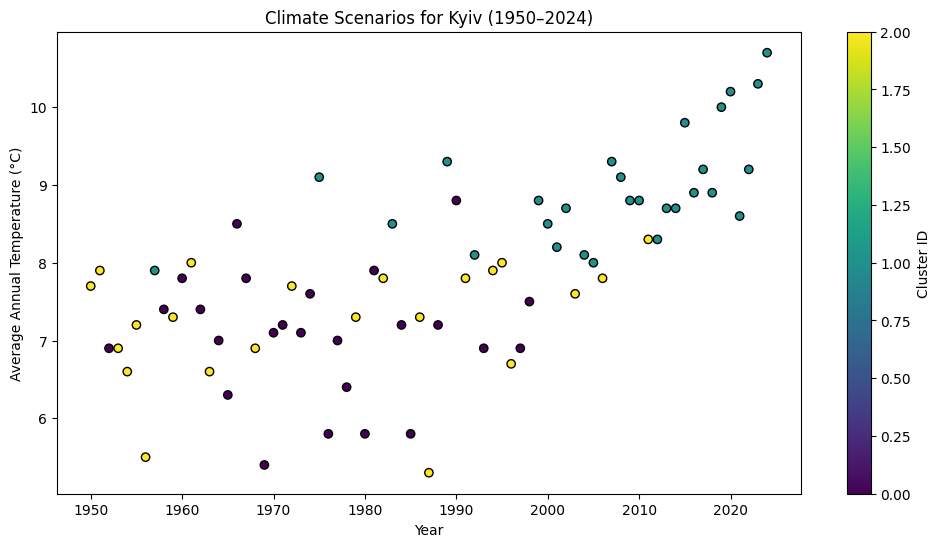

In [6]:
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_features['year'], df_features['avg_year_temp'], 
                      c=df_features['cluster'], cmap='viridis', edgecolors='k')

plt.colorbar(scatter, label='Cluster ID')
plt.title('Climate Scenarios for Kyiv (1950–2024)')
plt.xlabel('Year')
plt.ylabel('Average Annual Temperature (°C)')
plt.show()

The clustering analysis reveals a clear historical progression from a stable climate scenario to a transitional one. The stable scenario, represented by the purple points (Cluster 0), characterizes the baseline conditions that dominated the region from 1950 through the late 1980s. These years are defined by the lowest average annual temperatures, a higher frequency of rainy days, and a relative absence of significant thermal or hydrological stress . As the timeline moves into the late 1990s and the early 2000s, the teal points (Cluster 1) mark the transition toward a more stressed environment. This transitional scenario features a noticeable increase in average temperatures and a growing number of dry days, suggesting that the cooler historical norms are being steadily replaced by higher temperature regimes.  

The most concerning development is the emergence of the unfavorable or extreme climate scenario, indicated by the yellow points (Cluster 2). This scenario has appeared almost exclusively since 2010 and represents a qualitative structural shift in Kyiv's climate behavior rather than a simple gradual change. These years are characterized by the highest average temperatures, more frequent and intense heatwaves, and an exceptionally high number of days experiencing combined dry stress where low soil moisture and high evapotranspiration coincide. The concentration of these extreme clusters in the most recent observation period, including the projected characteristics for 2025, confirms that these severe conditions are becoming a regular feature of the local climate, highlighting an urgent need for adaptive water and heat management strategies.  

<h3>6. Comparison with 2025 Data</h3>

The final task is to evaluate the most recent data (2025) to determine which climate scenario it aligns with.

In [7]:
# Using 2025 indicators identified in the case study
# (avg_temp, median_temp, min_temp, max_temp, dry_days, rainy_days)
data_2025 = pd.DataFrame([[17.0, 15.3, -2.5, 38.4, 252, 94]], columns=X.columns)

# Standardize and predict the 2025 cluster
scaled_2025 = scaler.transform(data_2025)
predicted_cluster_2025 = kmeans.predict(scaled_2025)[0]

print(f"The year 2025 belongs to Cluster ID: {predicted_cluster_2025}")

The year 2025 belongs to Cluster ID: 1


Classifying 2025 into Cluster 1 indicates that the year aligns with a transitional climate scenario, signaling a clear departure from the "stable" historical baseline that dominated the mid-20th century. This placement suggests that the year is characterized by elevated average temperatures and a more frequent occurrence of thermal stress events, such as heatwaves, when compared to pre-2000 environmental norms. From a hydrological perspective, this classification implies a year defined by a higher concentration of dry days and a decrease in the number of rainy days, confirming that the local climate is no longer following the more balanced and predictable patterns of the past.  

<h3>Conclusion</h3>

The application of K-means clustering to aggregated annual indicators successfully identifies long-term structural shifts in Kyiv’s climate behavior, moving beyond simple temperature averages to reveal distinct environmental regimes. This transition from a stable baseline to increasingly frequent transitional and extreme scenarios highlights the growing prevalence of thermal and hydrological stress in the region. Classifying 2025 within the transitional cluster underscores that these shifts are not isolated anomalies but are part of a persistent trend that requires data-driven, locally adapted strategies for effective environmental risk mitigation. 